In [1]:
!pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pingouin scikit_posthocs xgboost -q
print("pip 설치 완료!")

pip 설치 완료!



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install -U imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [4]:
# ============================================================
# 데이터 소개
# ============================================================

# - 공정(Process) 데이터
#     - Shot ID: 주조 샷 고유 식별자
#     - Injection Speed: 용탕 주입 속도 (m/s)
#     - Die Temperature: 금형 온도 (°C)
#     - Casting Pressure: 주조 압력 (bar)
#     - Cooling Time: 냉각 시간 (s)

# - 센서(Sensor) 데이터
#     - Mold Temp Sensor: 금형 내 센서 온도 (°C)
#     - Hydraulic Pressure: 유압 압력 (bar)
#     - Vibration Sensor: 진동값 (Hz)
#     - Flow Rate Sensor: 유량 (L/min)

# - 불량(Defects) 데이터
#     - Defect Type: 발생한 불량 유형 (미성형, 박리, 기공, 평탄, 개재물 등)
#     - Defect Status: 양품(0) / 불량(1) 여부

## 데이터 로드

#### header를 사용하여 0행과 1행을 머리글 행으로 하는 멀티컬럼 생성

In [5]:
df = pd.read_csv('./data/DieCasting_Quality_Raw_Data.csv',header=[0,1])
df_origin = df.copy()
print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nArticles: {df.shape}")

print("\n[Data Info]")
df.info()

데이터 로드 완료!

Articles: (7535, 57)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float64
 12 

In [ ]:
#컬럼명 앞뒤 공백 제거

df.columns = pd.MultiIndex.from_tuples(
    [(col[0].strip(), col[1].strip()) for col in df.columns]
)

print(df.columns.tolist())

[('Process', 'id'), ('Process', 'Product_Type'), ('Process', 'Shot'), ('Process', 'Velocity_1'), ('Process', 'Velocity_2'), ('Process', 'Velocity_3'), ('Process', 'High_Velocity'), ('Process', 'Cylinder_Pressure'), ('Process', 'Rapid_Rise_Time'), ('Process', 'Biscuit_Thickness'), ('Process', 'Clamping_Force'), ('Process', 'Cycle_Time'), ('Process', 'Pressure_Rise_Time'), ('Process', 'Casting_Pressure'), ('Process', 'Spray_Time'), ('Process', 'Spray_1_Time'), ('Process', 'Spray_2_Time'), ('Sensor', 'Melting_Furnace_Temp'), ('Sensor', 'Air_Pressure'), ('Sensor', 'Air_Pressure_Min'), ('Sensor', 'Air_Pressure_Max'), ('Sensor', 'Coolant_Temp'), ('Sensor', 'Coolant_Temp_Min'), ('Sensor', 'Coolant_Temp_Max'), ('Sensor', 'Coolant_Pressure'), ('Sensor', 'Factory_Temp'), ('Sensor', 'Factory_Temp_Min'), ('Sensor', 'Factory_Temp_Max'), ('Sensor', 'Factory_Humidity'), ('Sensor', 'Factory_Humidity_Min'), ('Sensor', 'Factory_Humidity_Max'), ('Defects', 'Short_Shot_1'), ('Defects', 'Bubble_1'), ('Defe

## 샘플 데이터 확인


In [7]:
print("\n" + "="*60)
print("샘플 데이터")
print("="*60)
display(df.head())


샘플 데이터


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                      \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness Clamping_Force   
0               214           0.008                10            258   
1               217           0.008                11            257   
2               214           0.008                11            257   
3               217           0.008                11            257   
4               217           0.008                12            257   

                                                                          \
  Cycle_Time Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7              0.044             1037        7.8          0.7   
1       20.7              0.044             1052        7.8          0.7   
2       20.8              0.041             1037        7.8          0.7   
3       20.7              0.043             1051        7.8          0.7   
4       20.7              0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0             0   
4        0 

## 기초 통계량 확인

In [8]:
print("\n" + "="*60)
print("기초 통계")
print("="*60)
display(df.drop(columns=[
        ('Process', 'id'),
        ('Process', 'Product_Type'),
        ('Process', 'Shot')
    ]).describe())


기초 통계


Process                                                            \
        Velocity_1   Velocity_2   Velocity_3 High_Velocity Cylinder_Pressure   
count  7535.000000  7535.000000  7535.000000   7535.000000       7535.000000   
mean      0.148219     0.168801     0.191193      2.319210        239.655607   
std       0.007134     0.004720     0.011563      0.222041         23.305451   
min       0.134000     0.158000     0.172000      0.000000        107.000000   
25%       0.142000     0.166000     0.181000      2.134000        217.000000   
50%       0.144000     0.168000     0.188000      2.161000        239.000000   
75%       0.156000     0.170000     0.202000      2.523000        265.000000   
max       0.180000     0.212000     0.234000      2.744000        266.000000   

                                                                     \
      Rapid_Rise_Time Biscuit_Thickness Clamping_Force   Cycle_Time   
count     7535.000000       7535.000000    7535.000000  7535.000000   
mean         0.009596         14.309622     306.433311    27.735979   
std          0.002148          3.286284      57.274965     8.716156   
min          0.000000          0.000000     238.000000    20.200000   
25%          0.008000         11.000000     255.000000    20.900000   
50%          0.009000         13.000000     258.000000    22.600000   
75%          0.012000         17.000000     372.000000    35.900000   
max          0.021000         24.000000     388.000000   218.600000   

                                                                     \
      Pressure_Rise_Time Casting_Pressure   Spray_Time Spray_1_Time   
count        7535.000000      7535.000000  7535.000000  7535.000000   
mean            0.039348       856.944127     9.815979     1.409104   
std             0.003945       234.815490     1.842438     0.557060   
min             0.000000       516.000000     7.000000     0.700000   
25%             0.036000       596.000000     8.000000     0.800000   
50%             0.041000      1037.000000     9.700000     1.200000   
75%             0.043000      1053.000000    12.100000     2.000000   
max             0.046000      1164.000000    13.100000     2.500000   

                                 Sensor                                \
      Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
count  7535.000000          7535.000000  7535.000000           7535.0   
mean      1.396045           680.652661     6.109595              3.0   
std       0.716170            25.288666     0.647906              0.0   
min       0.700000           635.300000     4.600000              3.0   
25%       0.800000           656.700000     5.700000              3.0   
50%       0.800000           680.300000     6.200000              3.0   
75%       2.000000           703.100000     6.600000              3.0   
max       3.000000           730.000000     7.100000              3.0   

                                                                       \
      Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
count           7535.0  7535.000000           7535.0           7535.0   
mean               9.0    26.830126             10.0             50.0   
std                0.0     0.525149              0.0              0.0   
min                9.0    25.900000             10.0             50.0   
25%                9.0    26.500000             10.0             50.0   
50%                9.0    26.800000             10.0             50.0   
75%                9.0    27.200000             10.0             50.0   
max                9.0    28.100000             10.0             50.0   

                                                                       \
      Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
count      7535.000000  7445.000000           7445.0           7445.0   
mean          2.701155    32.829684             18.0             22.0   
std           0.052408     1.67489

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness)    7535 non-null   int64  
 10  (Process, Clamping_Force)       7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float64
 12  (Process, Pressure_Rise_Time)   7535 non-null

# 데이터 전처리

## 데이터 정제

### 중복 데이터 확인

In [10]:
print("\n" + "="*60)
print("중복 데이터 확인")
print("="*60)

# 전체 행 중복 확인
print("\n[전체 행 기준 중복]")
print(f"diecasting 중복: {df.duplicated().sum():,}건")


중복 데이터 확인

[전체 행 기준 중복]
diecasting 중복: 0건


## 결측치 처리

In [11]:
print("\n" + "="*60)
print("결측치 확인")
print("="*60)

missing_df = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측비율(%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df) > 0:
    print("\n[결측치 현황]")
    display(missing_df)
else:
    print("\n결측치 없음")


결측치 확인

[결측치 현황]


결측수  결측비율(%)
Sensor Factory_Temp           90     1.19
       Factory_Temp_Min       90     1.19
       Factory_Temp_Max       90     1.19
       Factory_Humidity       90     1.19
       Factory_Humidity_Min   90     1.19
       Factory_Humidity_Max   90     1.19

Factory_Temp 공장 온도 측정값 float64

Factory_Humidity 공장 습도 측정값 float64

### 히스토그램 및 기초통계량 확인 시, 평균보다는 중앙값으로 결측치를 채우는 게 좋다고 판단

In [22]:
print("\n" + "="*60)
print("결측치 처리")
print("="*60)

cols = [
    'Factory_Temp',
    'Factory_Temp_Min',
    'Factory_Temp_Max',
    'Factory_Humidity',
    'Factory_Humidity_Min',
    'Factory_Humidity_Max'
]

for col in cols:
    df[('Sensor', col)] = df[('Sensor', col)].fillna(
        df[('Sensor', col)].median()
    )

df.isnull().sum().sum()
print("중앙값으로 처리 완료!")


결측치 처리
중앙값으로 처리 완료!


In [13]:
print("\n" + "="*60)
print("결측치 확인")
print("="*60)

missing_df = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측비율(%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df) > 0:
    print("\n[결측치 현황]")
    display(missing_df)
else:
    print("\n결측치 없음")


결측치 확인

결측치 없음


## 히스토그램 생성

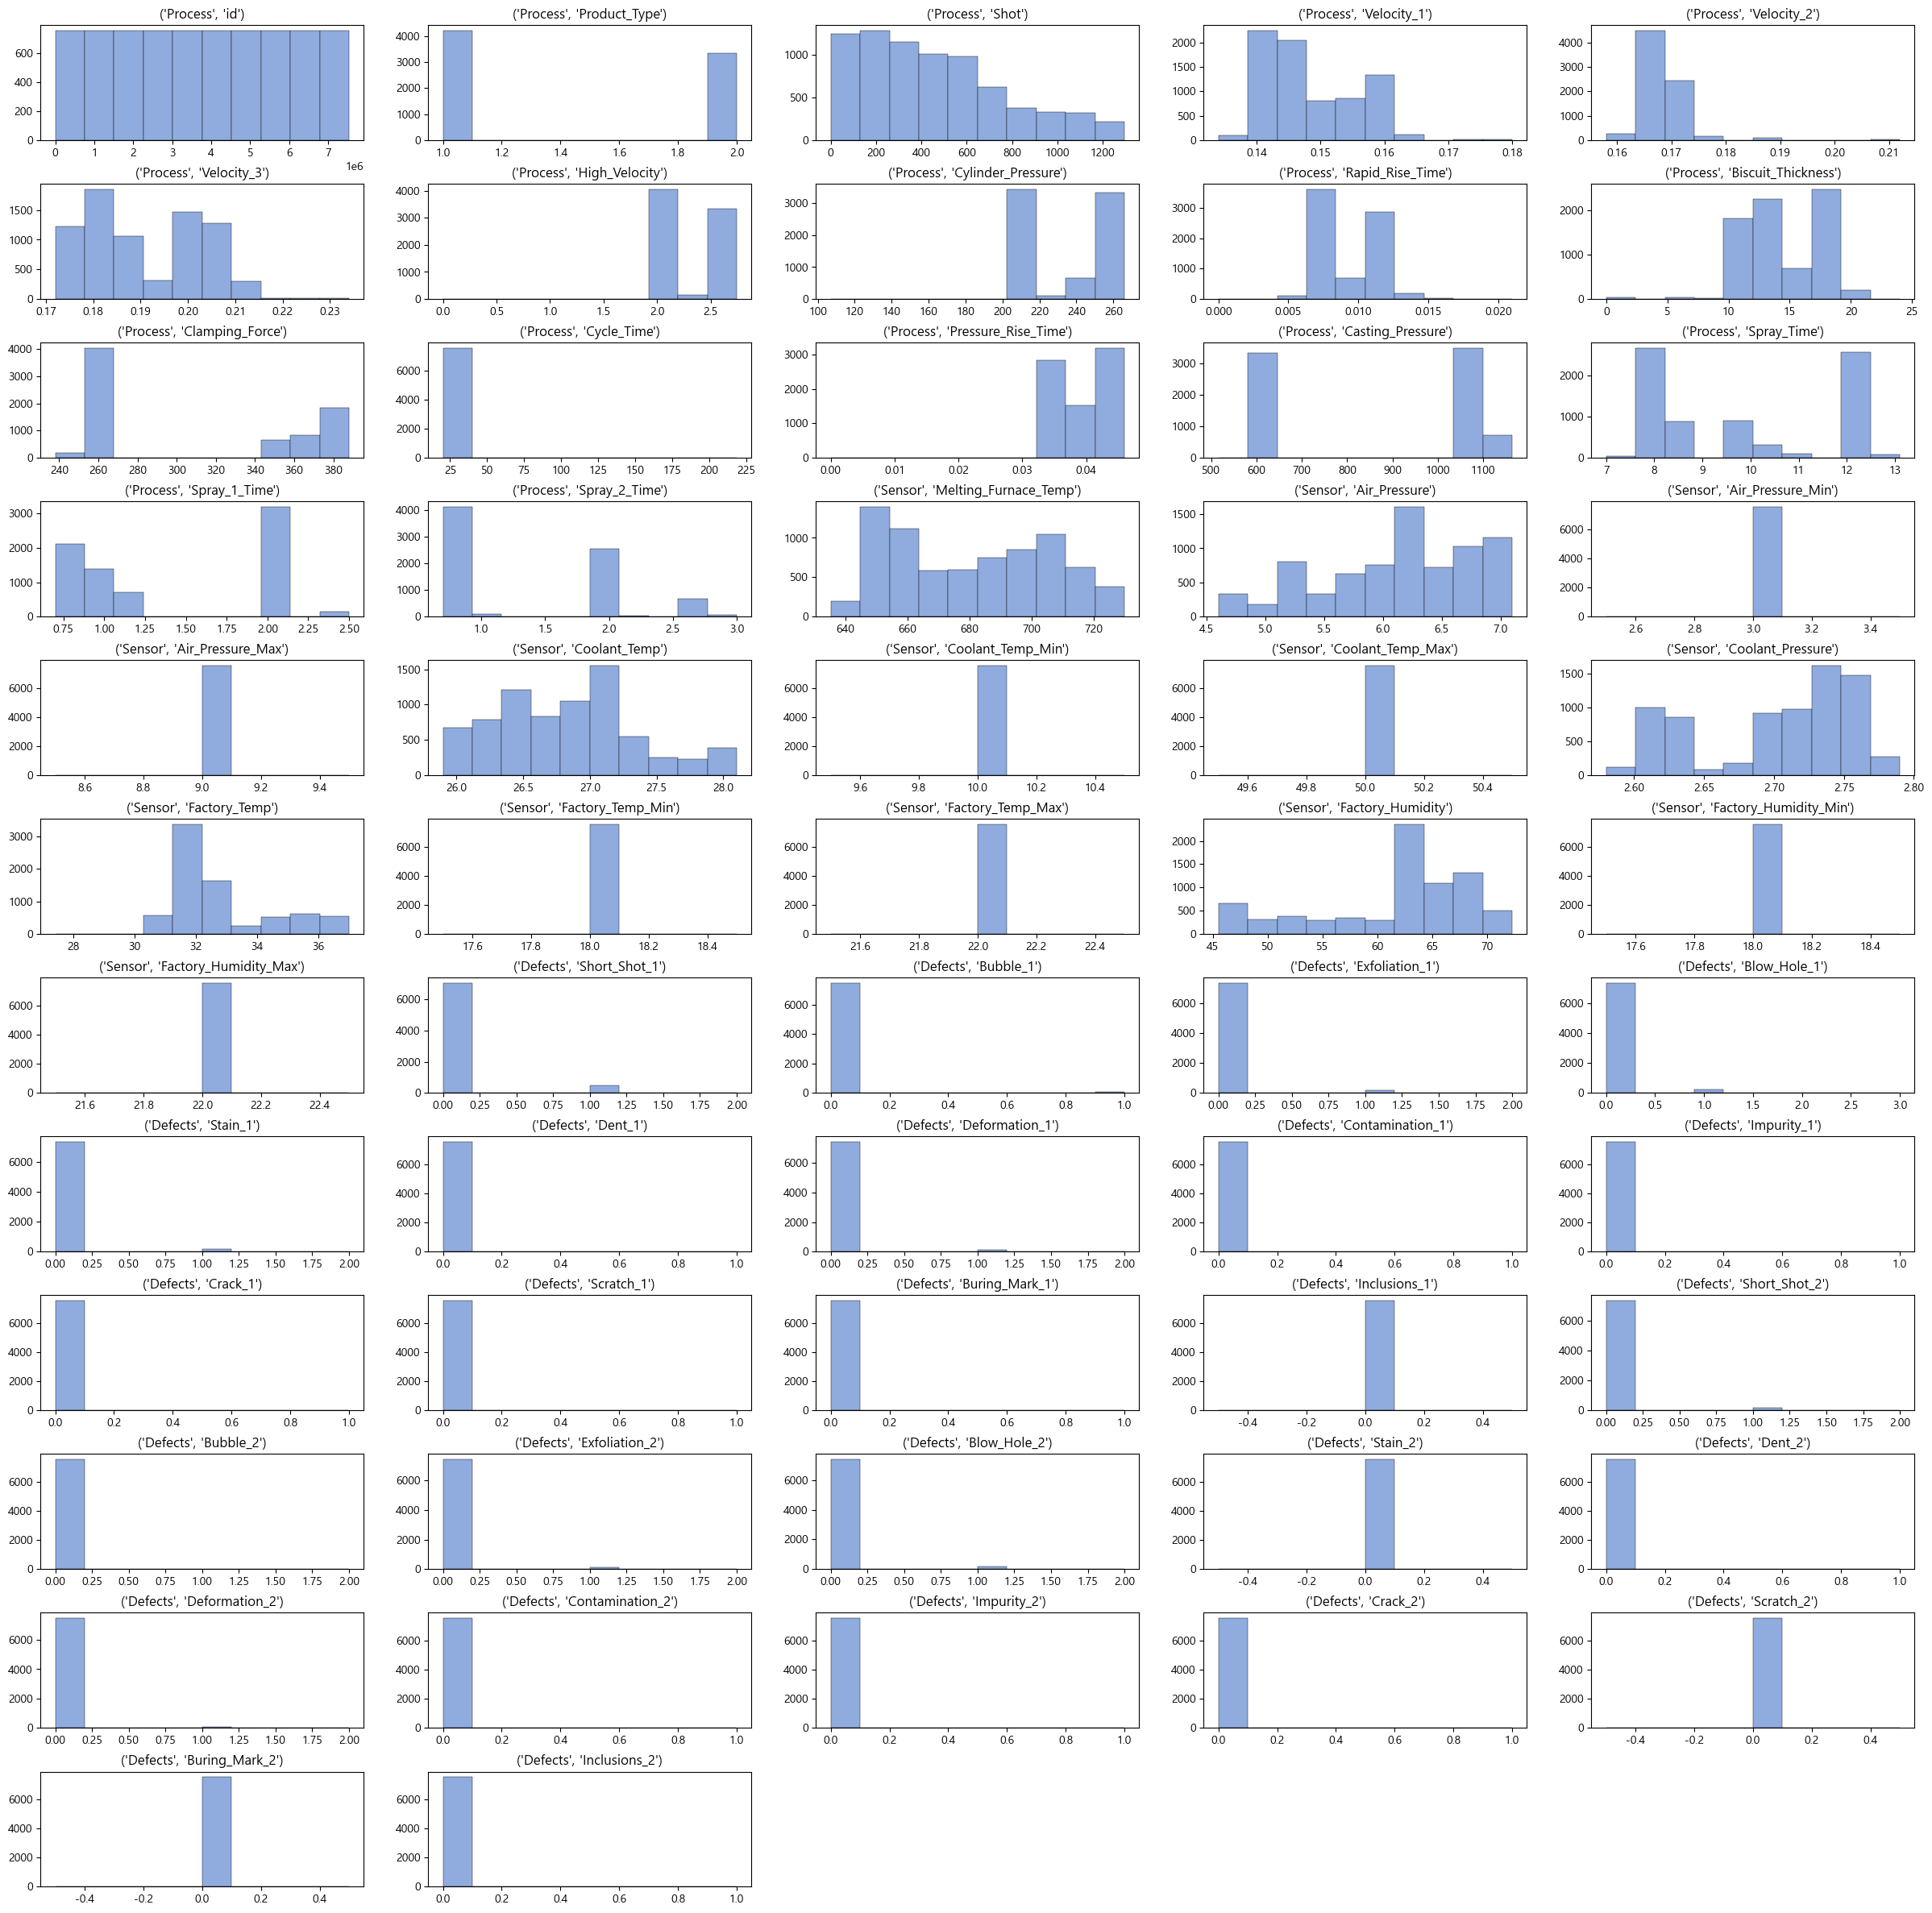

In [14]:
plt.figure(figsize=(30,30))
plt.subplots_adjust(hspace=0.38)
# 각 변수의 막대그래프 개수
for index,value in enumerate(df):
 sub=plt.subplot(12,5,index+1)
 sub.hist(df[value],facecolor=(144/255,171/255,221/255),
	 	 	 linewidth=.3,edgecolor='black')
 plt.title(value)

## 불량 개수 확인하기

### Defects가 0이나 1이 아닌 경우(2, 3) -> 1로 처리

In [15]:
defect_df = df['Defects']

# 1 초과 값이 하나라도 있는 컬럼
defect_over1 = defect_df.columns[(defect_df > 1).any()]
display(defect_over1)

# 1 초과 값을 모두 1로 변경
df['Defects'] = df['Defects'].clip(upper=1)

print("1 초과 값 개수:", (df['Defects'] > 1).sum().sum())

Index(['Short_Shot_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1',
       'Deformation_1', 'Short_Shot_2', 'Bubble_2', 'Exfoliation_2',
       'Blow_Hole_2', 'Deformation_2'],
      dtype='str')

1 초과 값 개수: 0


In [16]:
defect = defect_df.columns[(defect_df == 1).any()]
display(defect_df[defect])

ones_count = (defect_df == 1).sum()
ones_count = ones_count[ones_count > 0]
display(ones_count.sort_values(ascending=False))


,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Inclusions_2
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7530,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7531,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7532,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7533,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Short_Shot_1       482
Blow_Hole_1        199
Short_Shot_2       178
Exfoliation_1      171
Stain_1            169
Blow_Hole_2        149
Exfoliation_2      128
Deformation_1      107
Bubble_1            72
Deformation_2       63
Contamination_2      8
Dent_1               7
Buring_Mark_1        5
Bubble_2             5
Impurity_2           5
Dent_2               4
Contamination_1      4
Impurity_1           2
Crack_2              2
Scratch_1            2
Crack_1              1
Inclusions_2         1
dtype: int64

### 센서 데이터(Sensor 변수)의 이상치 탐색 및 처리

In [17]:
sensor_df = df['Sensor']
Q1 = sensor_df.quantile(0.25)
Q3 = sensor_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (sensor_df < lower_bound) | (sensor_df > upper_bound)
outlier_count = outlier_mask.sum()
display(outlier_count.sort_values(ascending=False))

Factory_Temp            374
Melting_Furnace_Temp      0
Air_Pressure_Min          0
Air_Pressure_Max          0
Coolant_Temp              0
Air_Pressure              0
Coolant_Temp_Min          0
Coolant_Temp_Max          0
Coolant_Pressure          0
Factory_Temp_Min          0
Factory_Temp_Max          0
Factory_Humidity          0
Factory_Humidity_Min      0
Factory_Humidity_Max      0
dtype: int64

### 이상치가 불량 발생과 연관있는 값인가? -> 이 경우 제거하지 말고 이상치 플래그 변수 추가 하는 방법이 있음

In [18]:
df['Defect_Status'] = df['Defects'].max(axis=1) #한 행에 불량이 하나라도 있으면 1
df['Defect_Status'] = df['Defect_Status'].map({
    0: 'Normal',
    1: 'Defective'
})

outlier_rows = outlier_mask.any(axis=1) #이상치가 하나라도 있으면 True
outlier_rows = outlier_rows.map({
    False : 'No_outlier',
    True : 'Outlier'
})

# 이상치 없는 행들(False) 중 정상/불량 비율 vs 이상치 있는 행들(True) 중 정상/불량 비율을 비교하는 표
result_table = pd.crosstab(
    outlier_rows,
    df['Defect_Status'],
    normalize='index'
)

display(result_table)

print("\n" + "="*60)
print("해석")
print("="*60)
print("이상치가 있을 경우 불량률이 22.18% -> 27.01%로 약 4.83%p 증가")
print("상대 증가율은 27.01/22.18 = 1.22로 약 22% 더 높은 것으로 확인됨") 
print("통계적으로 유의한지는 카이제곱 검정으로 확인 필요")

Defect_Status,Defective,Normal
row_0,,
No_outlier,0.221757,0.778243
Outlier,0.270053,0.729947



해석
이상치가 있을 경우 불량률이 22.18% -> 27.01%로 약 4.83%p 증가
상대 증가율은 27.01/22.18 = 1.22로 약 22% 더 높은 것으로 확인됨
통계적으로 유의한지는 카이제곱 검정으로 확인 필요


#### 이상치 여부와 불량 발생 간 관계가 통계적으로 유의한지 확인해보기 -카이제곱 검정

In [19]:
print("\n" + "="*60)
print("카이제곱 검정 환경 세팅-비율에서 개수로")
print("="*60)


from scipy.stats import chi2_contingency

# 개수 테이블 (normalize 제거!)
contingency_table = pd.crosstab(
    outlier_rows,
    df['Defect_Status']
)

display(contingency_table)


카이제곱 검정 환경 세팅-비율에서 개수로


Defect_Status,Defective,Normal
row_0,,
No_outlier,1588,5573
Outlier,101,273


In [20]:
print("\n" + "="*60)
print("카이제곱 검정 결과")
print("="*60)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print("")

print("p-value가 0.03으로 0.05보다 작으므로, 이상치 여부와 불량 발생 사이에는 통계적으로 유의한 관계가 있다.")
print("Cramer's V로 효과 크기 확인해보기")


카이제곱 검정 결과
Chi-square statistic: 4.4937
p-value: 0.034021
Degrees of freedom: 1

p-value가 0.03으로 0.05보다 작으므로, 이상치 여부와 불량 발생 사이에는 통계적으로 유의한 관계가 있다.
Cramer's V로 효과 크기 확인해보기


In [21]:
print("\n" + "="*60)
print("Cramer's V 계산")
print("="*60)

n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

print(f"Cramer's V: {cramers_v:.4f}")

print("")
print("Cramer's V 값이 0.2이므로 약한 관계일 가능성이 높다.")
print("이상치라고 제거하기보다는 놔두는 것이 좋을 것으로 판단...")


Cramer's V 계산
Cramer's V: 0.0244

Cramer's V 값이 0.2이므로 약한 관계일 가능성이 높다.
이상치라고 제거하기보다는 놔두는 것이 좋을 것으로 판단...


## 불량 비율 분석하기
_______________________
현재 데이터 상태

각 행 = 제품 1개

Defects 안의 여러 컬럼 = 결함 유형

값 1 = 해당 결함 존재

👉 따라서 한 제품에 결함이 하나라도 있으면 불량

In [24]:
# 제품 단위 불량 여부 (하나라도 1이면 불량)
df[('Target','is_defect')] = (df['Defects'].sum(axis=1) > 0).astype(int)

print(df[('Target','is_defect')].value_counts())

(Target, is_defect)
0    5846
1    1689
Name: count, dtype: int64


In [25]:
print("\n" + "="*60)
print("전체 불량률 분석")
print("="*60)

total = len(df)
defect_cnt = df[('Target','is_defect')].sum()
defect_rate = defect_cnt / total * 100

print(f"총 생산 수량: {total}")
print(f"총 불량 수량: {defect_cnt}")
print(f"불량률: {defect_rate:.2f}%")


전체 불량률 분석
총 생산 수량: 7535
총 불량 수량: 1689
불량률: 22.42%


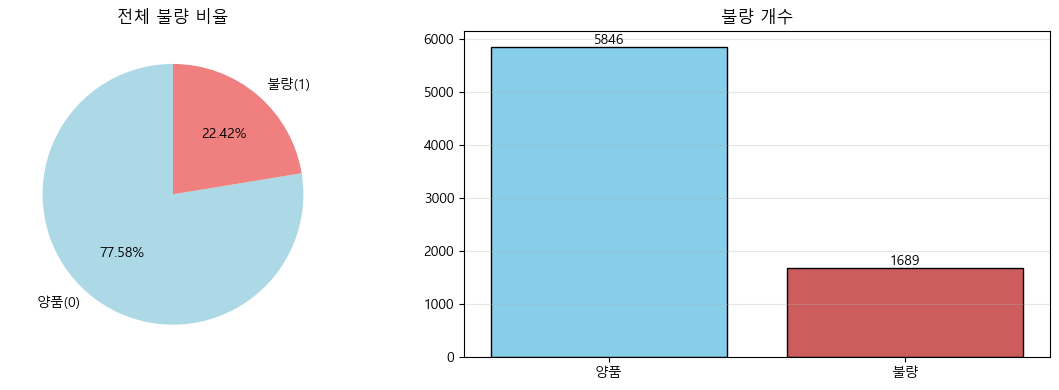

In [ ]:
# 시각화

counts = df[('Target','is_defect')].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# ================================
# 파이차트
# ================================
axes[0].pie(counts,
            labels=['양품(0)','불량(1)'],
            autopct='%1.2f%%',
            colors=['lightblue','lightcoral'],
            startangle=90)
axes[0].set_title("전체 불량 비율")

# ================================
# 바차트
# ================================
bars = axes[1].bar(['양품','불량'],
                   counts,
                   color=['skyblue','indianred'],
                   edgecolor='black')

axes[1].set_title("불량 개수")
axes[1].grid(axis='y', alpha=0.3)

# 숫자 표시
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        #fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 결함 유형별 불량 기여도

In [27]:
defect_sum = df['Defects'].sum().sort_values(ascending=False)

contribution = defect_sum / defect_cnt * 100
contribution = contribution.sort_values(ascending=False)

print("결함 기여도 Top 10")
display(contribution.head(10))

결함 기여도 Top 10


Short_Shot_1     29.425696
Blow_Hole_1      13.084665
Stain_1          11.190053
Short_Shot_2     10.657194
Exfoliation_1    10.242747
Blow_Hole_2       9.177028
Exfoliation_2     7.756069
Deformation_1     6.394316
Bubble_1          4.262877
Deformation_2     3.789224
dtype: float64

## 공정 변수(Process)와 불량 발생(Defects) 간 관계 분석